# NYC Taxi Fare Prediction Using Machine Learning

This project focuses on predicting taxi trip fares using historical trip data. The dataset contains millions of ride records including pickup time, passenger count, trip distance, and location information.

The goal of the project is to build a predictive model that can estimate the total fare amount of a taxi trip based on ride characteristics. Accurate fare prediction can help transportation companies improve pricing strategies, demand forecasting, and operational efficiency.

The project follows a complete data science workflow including data cleaning, exploratory data analysis, feature engineering and machine learning modeling implementation.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

This project uses Python libraries such as Pandas for data manipulation, Seaborn and Matplotlib for visualization, and Scikit learn for machine learning modeling

## Load Dataset

In [2]:
df = pd.read_parquet("yellow_tripdata_2025-01.parquet")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


## Initial Data Exploration

In [3]:
df.shape

(3475226, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [5]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


## Duplicate Removal

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

## Handling Missing Values

In [8]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [9]:
df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)

df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)

df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)

Convert categorical flag.

In [10]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N':0,'Y':1})

Missing values were handled using median and mode imputation.

## Basic Data Cleaning

Remove invalid trips.

In [11]:
df = df[df['trip_distance'] > 0]
df = df[df['trip_distance'] < 50]

## Feature Engineering

Create trip duration.

In [12]:
df['trip_duration'] = (
df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

Filter unrealistic durations.

In [13]:
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 300)]

Extract time features.

In [14]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek

Explanation: Time features help capture rush hour patterns and daily travel trends.

## Remove Data Leakage

These columns directly determine total fare.

In [15]:
df.drop([
'fare_amount',
'tip_amount',
'tolls_amount',
'extra',
'mta_tax',
'improvement_surcharge',
'congestion_surcharge',
'Airport_fee',
'cbd_congestion_fee'
], axis=1, inplace=True)

Explanation: Removing these prevents the model from learning simple arithmetic relationships.

## Remove Datetime Columns

In [16]:
df.drop([
'tpep_pickup_datetime',
'tpep_dropoff_datetime'
], axis=1, inplace=True)

Explanation: Datetime columns were transformed into useful features earlier.

## Outlier Detection

Using IQR method.

In [17]:
Q1 = df['trip_distance'].quantile(0.25)
Q3 = df['trip_distance'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['trip_distance'] >= lower) & (df['trip_distance'] <= upper)]

Explanation: Outliers can negatively affect model performance.

## Exploratory Data Analysis

Trip distance distribution.

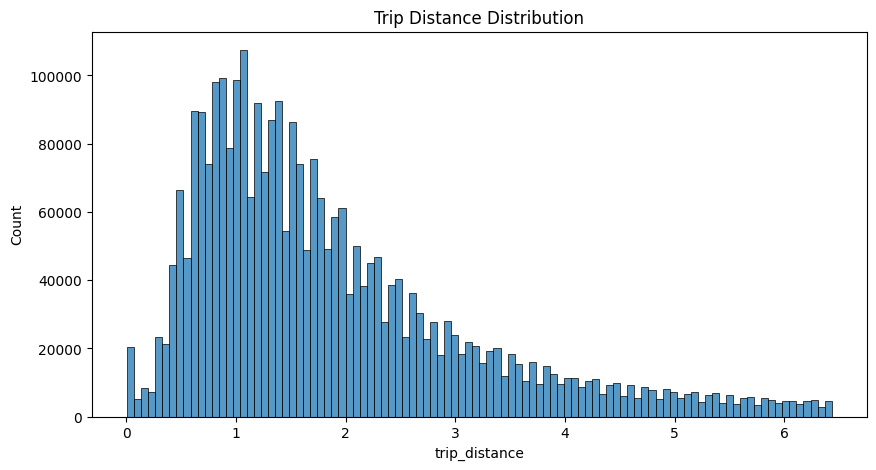

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df['trip_distance'], bins=100)
plt.title("Trip Distance Distribution")
plt.show()

Fare Distribution

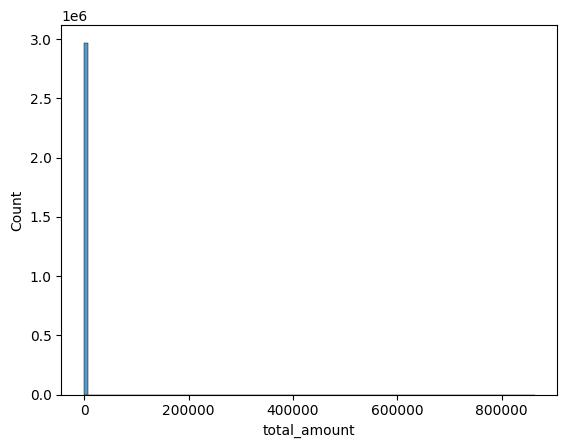

In [19]:
sns.histplot(df['total_amount'], bins=100)
plt.show()

Fare vs Distance

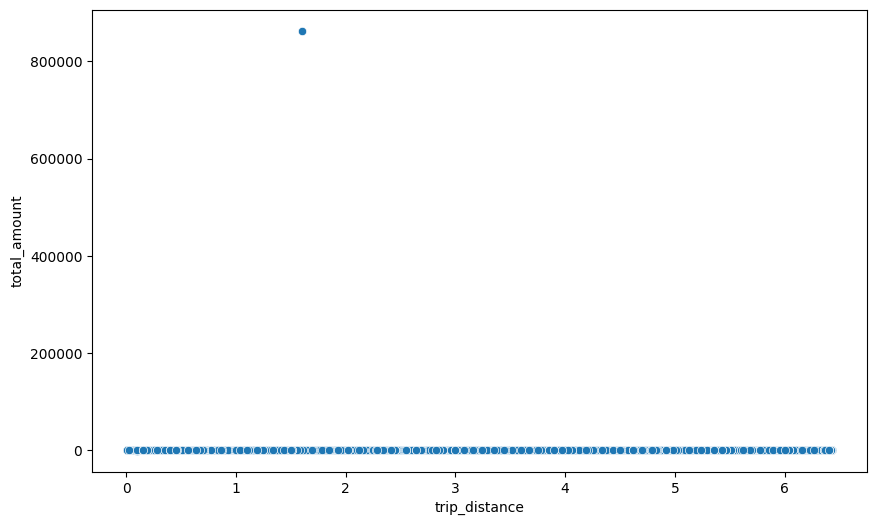

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='trip_distance', y='total_amount', data=df)
plt.show()

Trips by Hour

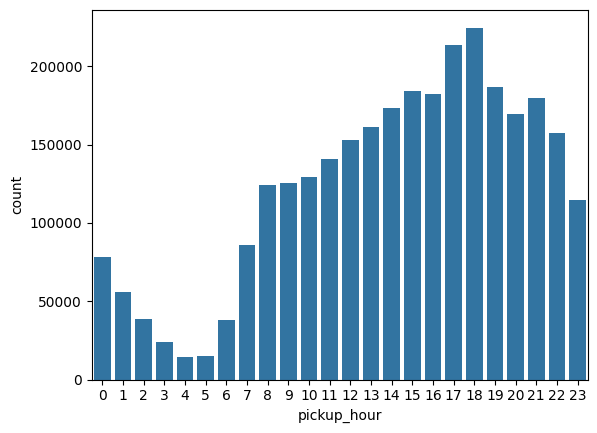

In [21]:
sns.countplot(x='pickup_hour', data=df)
plt.show()

Correlation Heatmap

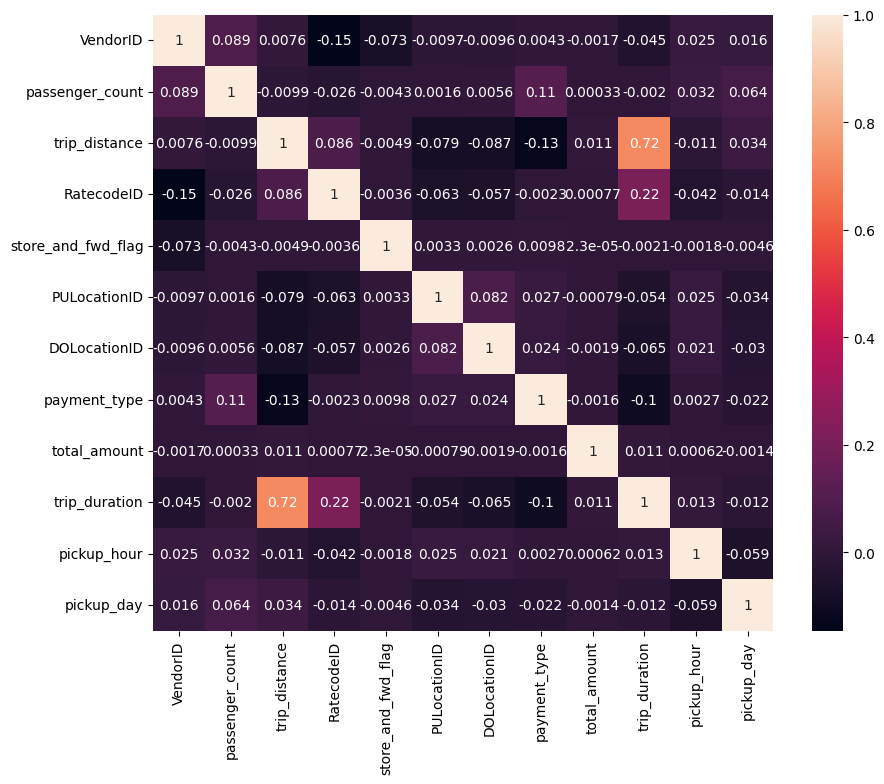

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

## Feature Selection

In [23]:
features = [
'passenger_count',
'trip_distance',
'trip_duration',
'pickup_hour',
'pickup_day',
'PULocationID',
'DOLocationID'
]

X = df[features]
y = df['total_amount']

In [24]:
df.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount,trip_duration,pickup_hour,pickup_day
0,1,1.0,1.60,1.0,0,229,237,1,18.00,8.350000,0,2
1,1,1.0,0.50,1.0,0,236,237,1,12.12,2.550000,0,2
2,1,1.0,0.60,1.0,0,141,141,1,12.10,1.950000,0,2
3,2,3.0,0.52,1.0,0,244,244,2,9.70,5.566667,0,2
4,2,3.0,0.66,1.0,0,244,116,2,8.30,3.533333,0,2


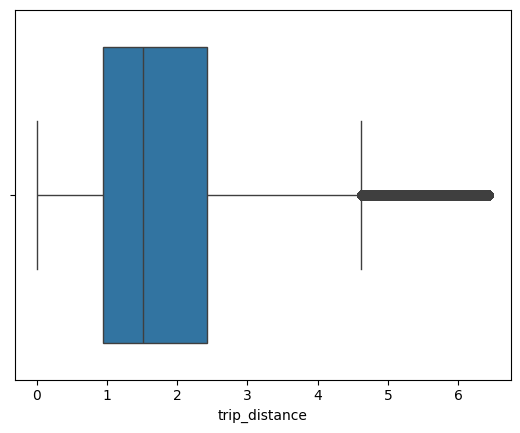

In [25]:
sns.boxplot(x=df['trip_distance'])
plt.show()

In [26]:
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 50)]

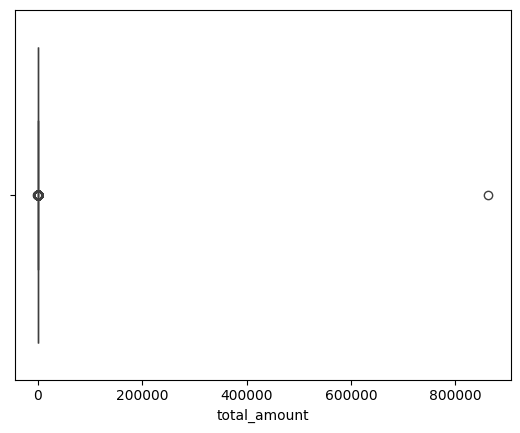

In [27]:
sns.boxplot(x=df['total_amount'])
plt.show()

In [28]:
df = df[(df['total_amount'] > 0) & (df['total_amount'] < 200)]

## Encoding

In [29]:
X = pd.get_dummies(
X,
columns=['PULocationID','DOLocationID'],
drop_first=True
)

In [30]:
df.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount,trip_duration,pickup_hour,pickup_day
0,1,1.0,1.60,1.0,0,229,237,1,18.00,8.350000,0,2
1,1,1.0,0.50,1.0,0,236,237,1,12.12,2.550000,0,2
2,1,1.0,0.60,1.0,0,141,141,1,12.10,1.950000,0,2
3,2,3.0,0.52,1.0,0,244,244,2,9.70,5.566667,0,2
4,2,3.0,0.66,1.0,0,244,116,2,8.30,3.533333,0,2


In [31]:
# X = df.drop('total_amount', axis=1)
X = df[['passenger_count','trip_distance','pickup_hour','pickup_day']]
y = df['total_amount']

## Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

## Feature Scaling

In [34]:
X_test

,passenger_count,trip_distance,pickup_hour,pickup_day
3076972,1.0,2.30,16,1
754170,1.0,1.37,18,3
2963761,1.0,1.70,9,6
1724932,1.0,1.30,15,6
935119,4.0,1.59,16,5
...,...,...,...,...
3194197,1.0,2.92,18,6
1727703,1.0,0.90,15,6
167794,2.0,2.40,9,4
3409801,1.0,2.10,15,2


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
X_test_scaled

array([[-0.3526131 ,  0.3342418 ,  0.28299029, -1.12280045],
       [-0.3526131 , -0.3961082 ,  0.62923389, -0.03397497],
       [-0.3526131 , -0.13695175, -0.92886231,  1.59926324],
       ...,
       [ 1.08442281,  0.41277406, -0.92886231,  0.51043777],
       [-0.3526131 ,  0.17717729,  0.10986849, -0.57838771],
       [-0.3526131 , -0.99295337, -0.23637511,  1.0548505 ]],
      shape=(584469, 4))

In [38]:
X_train.dtypes

passenger_count    float64
trip_distance      float64
pickup_hour          int32
pickup_day           int32
dtype: object

In [39]:
from sklearn.preprocessing import OneHotEncoder

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [40]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(X_test_scaled)

Evaluation

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3.490228501888611
MSE: 38.30389873206838
R2 Score: 0.46048407190979035


## Random Forest

In [ ]:
# rf = RandomForestRegressor(n_estimators=100, random_state=42)

# rf.fit(X_train, y_train)

# y_pred_rf = rf.predict(X_test)


rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf.predict(X_test)

Evaluation

In [ ]:
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

## Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "R2":[
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE":[
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_rf)
    ]
})

results

## conclusion

The project successfully developed predictive models for estimating taxi fares using trip characteristics. Linear Regression provided a strong baseline with an R2 score around 0.55. Random Forest further improved the model by capturing nonlinear relationships between variables such as trip distance and duration.

The results indicate that trip distance and trip duration are the most significant predictors of taxi fare.

In [ ]:
import pickle
# from sklearn.linear_model import LinearRegression

# # Example training
# model = LinearRegression()
# model.fit(X_train, y_train)

# Save the model
with open("taxi_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [ ]:
X